# Gene-Range Perturbation — Multi-Slide Analysis

In [1]:
%matplotlib inline
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 200,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

RED_LIGHT = '#FC9272'   # Global logFC
RED_MID   = '#CB181D'   # Cell-type-specific logFC
RED_DARK  = '#67000D'   # Edge swap baseline

# kept for cell-7 boxplots
BLUE   = '#2166AC'
ORANGE = '#D6604D'
GREEN  = '#4DAC26'

TOP_N_PERTURB_VALUES = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000]

## 1. Load results across all slides

In [2]:
results_root = 'results/gene_range3k/'
csvs = sorted(glob.glob(f'{results_root}/*/results.csv'))

dfs = []
for p in csvs:
    sid = int(Path(p).parent.name)
    df = pd.read_csv(p)
    df['slide_id'] = sid
    dfs.append(df)

if not dfs:
    raise FileNotFoundError(f'No results.csv files found under {results_root}/*/. Run perturb_gene_range.py first.')

all_df = pd.concat(dfs, ignore_index=True)
slide_ids = sorted(all_df['slide_id'].unique().tolist())
print(f'Loaded {len(dfs)} slide(s): {slide_ids}')
print(f'Total rows: {len(all_df)}')

# Convenience subsets
sweep_mean    = all_df[(all_df['cell_type'] == 'mean') & all_df['top_n_perturb'].notna()].copy()
baseline_mean = all_df[(all_df['cell_type'] == 'mean') & all_df['top_n_perturb'].isna()].copy()
ct_at_200     = all_df[(all_df['top_n_perturb'] == 200) & (all_df['cell_type'] != 'mean')].copy()
ct_baseline   = all_df[all_df['top_n_perturb'].isna() & (all_df['cell_type'] != 'mean')].copy()

sweep_mean['top_n_perturb'] = sweep_mean['top_n_perturb'].astype(int)

Loaded 6 slide(s): [120, 210, 221, 231, 232, 242]
Total rows: 1007


## 2. Summary plot with CI across slides

In [3]:
all_df.sort_values("spearman_r")

,pearson_r,spearman_r,precision,direction_match,edistance,edistance_local,rmse_log1p,strategy,cell_type,top_n_perturb,slide_id
511,-0.397087,-0.538439,0.24,0.083333,11.546675,7.070741,2087.479736,ctspec,Smooth_muscle,2000.0,221
520,-0.522453,-0.530948,0.32,0.062500,12.218107,7.465421,2096.642090,global,Smooth_muscle,3000.0,221
514,-0.616755,-0.529508,0.16,0.000000,8.201765,5.120476,295.317383,global,B_cell,3000.0,221
529,-0.458675,-0.513277,0.26,0.076923,10.873310,6.345147,2075.927246,ctspec,Smooth_muscle,3000.0,221
510,-0.536607,-0.492341,0.10,0.000000,9.146726,5.227121,1379.084961,ctspec,Plasma_cell,2000.0,221
...,...,...,...,...,...,...,...,...,...,...,...
733,0.994516,0.975222,0.82,1.000000,0.373942,0.400928,31103.824219,ctspec,Epithelial,50.0,232
781,0.995632,0.977623,0.88,1.000000,0.503397,0.435101,30970.130859,ctspec,Epithelial,500.0,232
749,0.995533,0.977719,0.84,1.000000,0.326520,0.385265,31069.302734,ctspec,Epithelial,100.0,232
685,0.996823,0.980120,0.88,1.000000,0.334362,0.281226,31027.212891,edge_swap,Epithelial,NaN,232


In [4]:
all_df['slide_id'].unique()

array([120, 210, 221, 231, 232, 242])

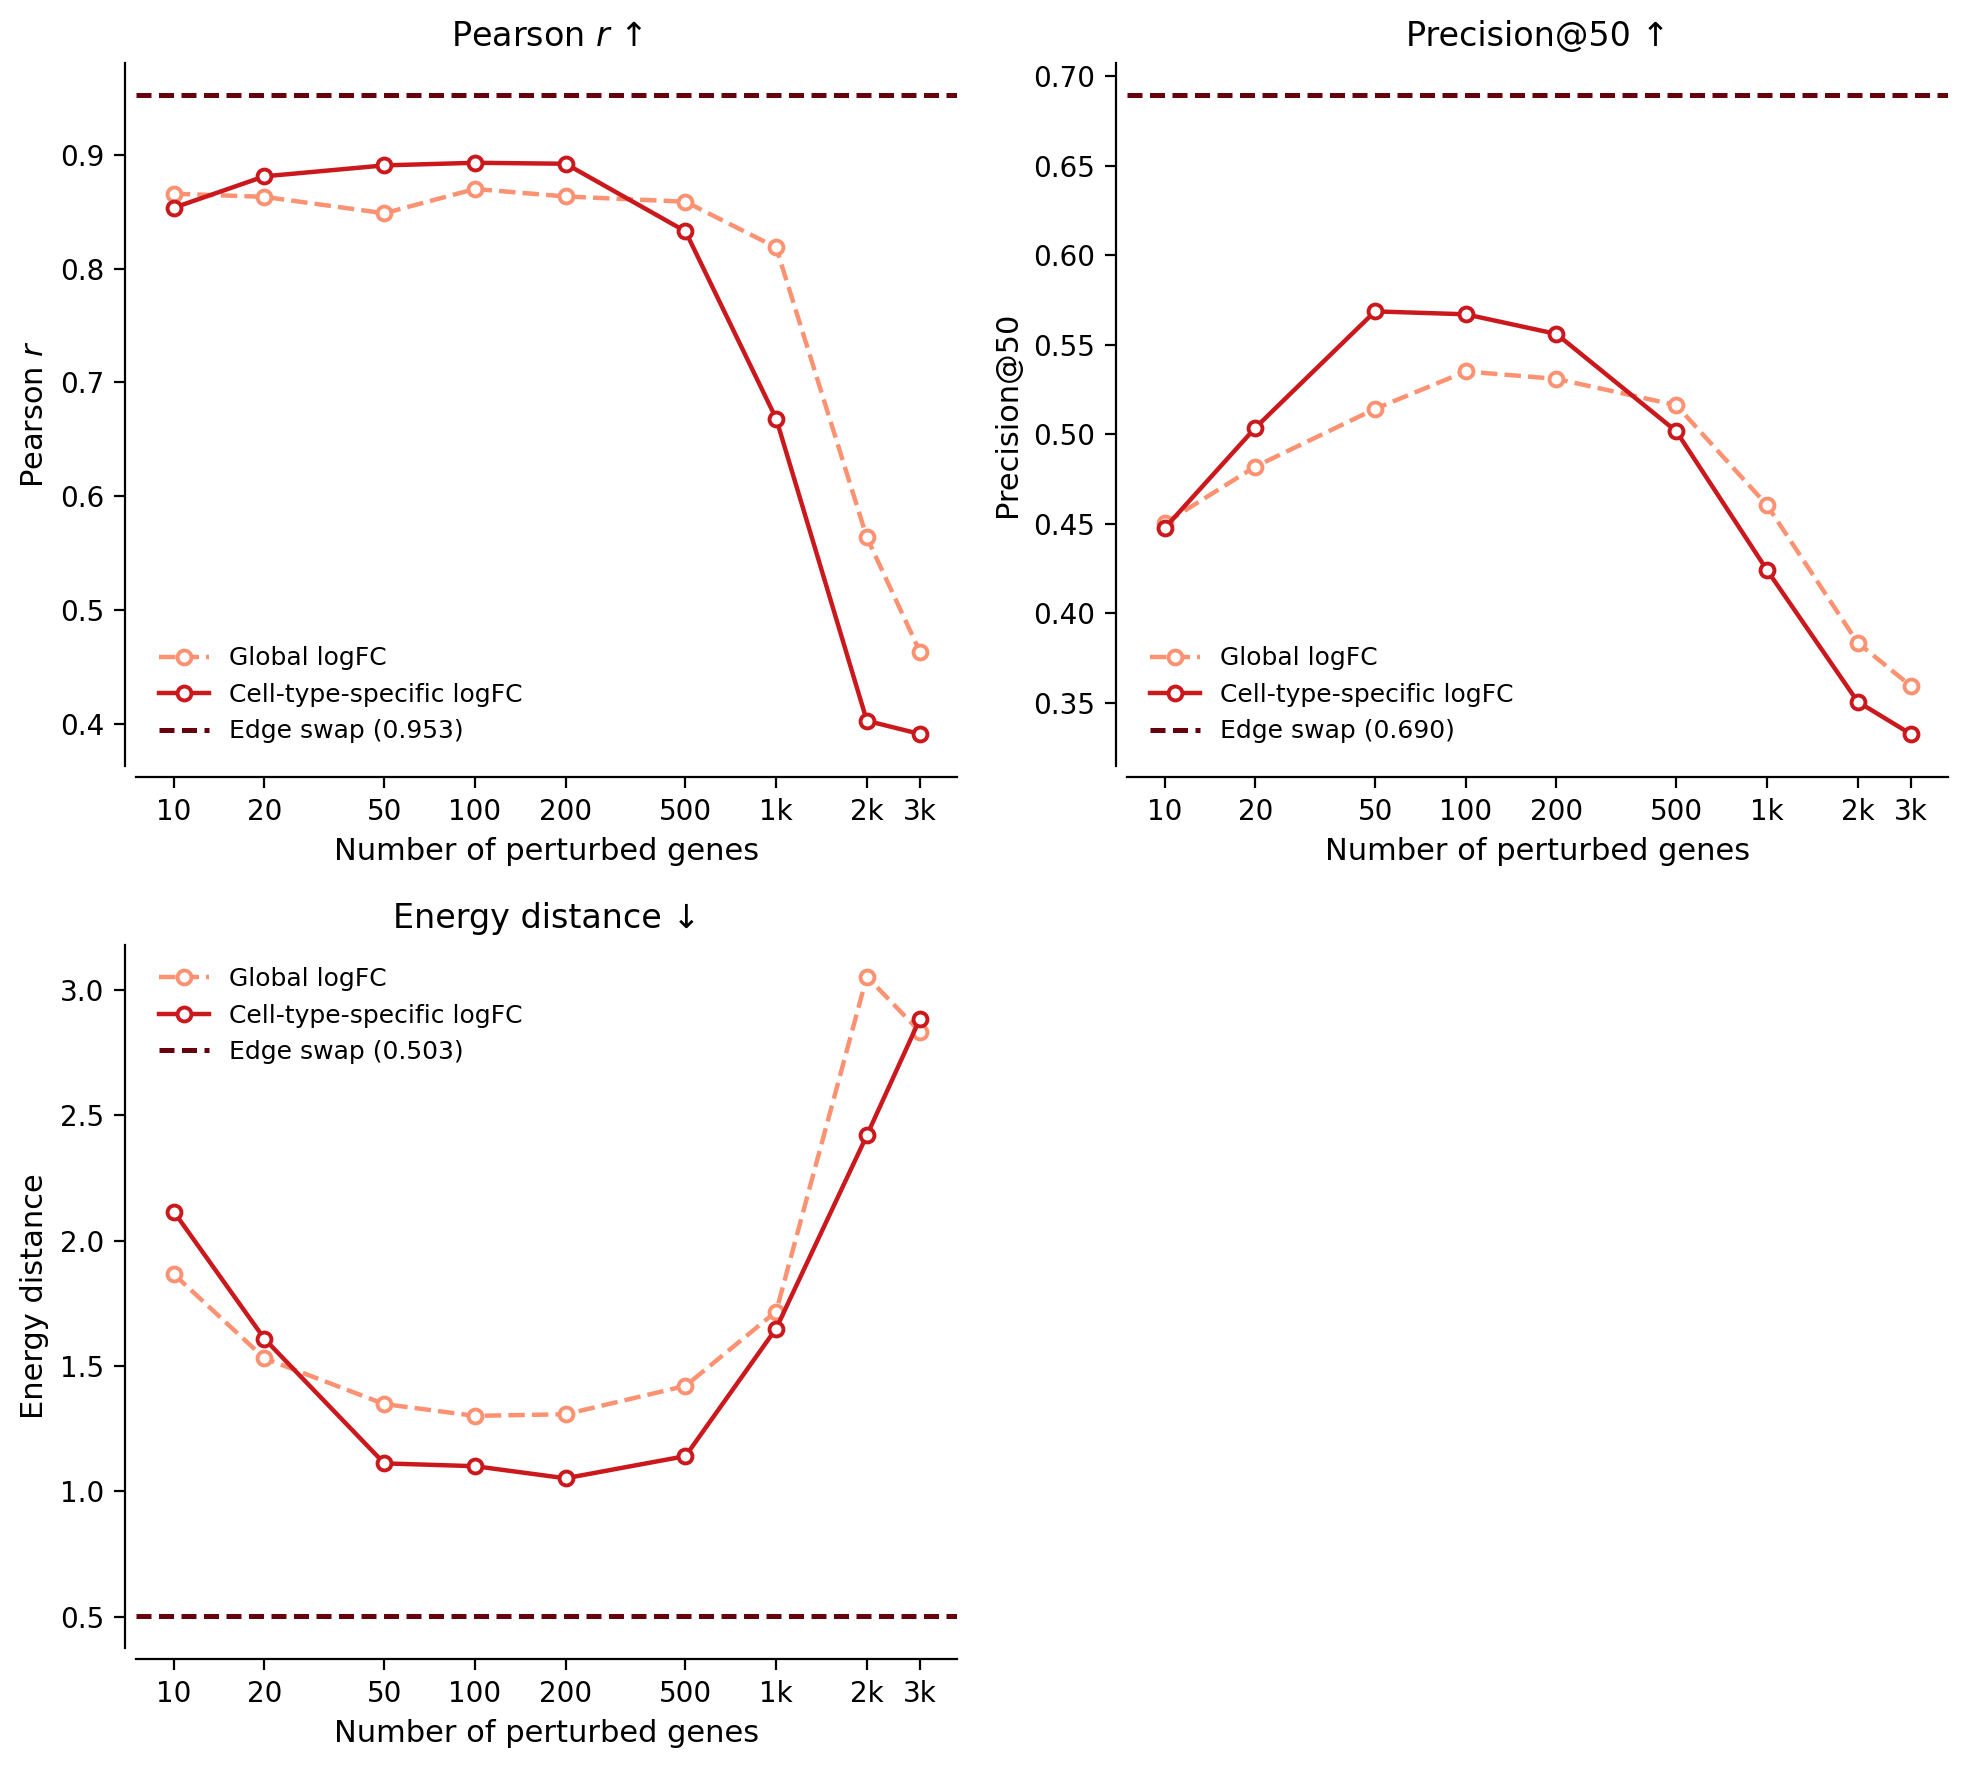

In [10]:
metrics_spec = [
    ('pearson_r',       'Pearson $r$',             True),
    # ('spearman_r',      'Spearman $r$',             True),
    ('precision',       'Precision@50',             True),
    # ('direction_match', 'Direction match',           True),
    # ('edistance',       'Energy distance',           False),
    ('edistance_local', 'Energy distance',   False),
    # ('rmse_log1p',      'RMSE log1p',               False),
]

TICK_LABELS = ['10', '20', '50', '100', '200', '500', '1k', '2k', '3k']

ncols = 2
nrows = -(-len(metrics_spec) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.0, nrows * 4.5))
axes = axes.flatten()

for i, (metric, ylabel, higher_better) in enumerate(metrics_spec):
    ax = axes[i]
    arrow = ' ↑' if higher_better else ' ↓'

    for strategy, color, ls, label in [
        ('global', RED_LIGHT, '--', 'Global logFC'),
        ('ctspec', RED_MID,   '-',  'Cell-type-specific logFC'),
    ]:
        sub = sweep_mean[sweep_mean['strategy'] == strategy]
        grp = sub.groupby('top_n_perturb')[metric]
        means = grp.mean().reindex(TOP_N_PERTURB_VALUES)
        stds  = grp.std(ddof=1).reindex(TOP_N_PERTURB_VALUES).fillna(0)
        x = means.index.tolist()

        ax.plot(x, means, color=color, ls=ls, lw=1.6,
                marker='o', ms=5, markerfacecolor='white', markeredgewidth=1.4,
                label=label, zorder=3)

    # Edge-swap baseline (mean only)
    bl = baseline_mean[baseline_mean['strategy'] == 'edge_swap'][metric]
    bl_mean = bl.mean()
    ax.axhline(bl_mean, color=RED_DARK, ls=(0, (3, 1.5)), lw=1.8,
               label=f'Edge swap ({bl_mean:.3f})', zorder=2)

    ax.set_xscale('log')
    ax.set_xticks(TOP_N_PERTURB_VALUES)
    ax.set_xticklabels(TICK_LABELS, rotation=45, ha='right')
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.set_xlabel('Number of perturbed genes')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + arrow)
    ax.spines['left'].set_position(('outward', 4))
    ax.spines['bottom'].set_position(('outward', 4))
    ax.legend(frameon=False, handlelength=2.0, fontsize=9)

for j in range(len(metrics_spec), len(axes)):
    axes[j].set_visible(False)

# fig.suptitle(f'Slides: {slide_ids}', fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

In [6]:
metrics = [m for m, _, _ in metrics_spec]

# Per-(strategy, top_n) aggregation — one row per point on the plot
agg = (
    sweep_mean[sweep_mean['strategy'].isin(['global', 'ctspec'])]
    .groupby(['strategy', 'top_n_perturb'])[metrics]
    .agg(['mean', 'std'])
    .reindex(TOP_N_PERTURB_VALUES, level='top_n_perturb')
)

# Edge-swap baseline (one number per metric — the dashed horizontal line)
baseline = (
    baseline_mean[baseline_mean['strategy'] == 'edge_swap'][metrics]
    .mean()
    .rename('edge_swap_mean')
)

## 3. Per-cell-type boxplots at 200 genes

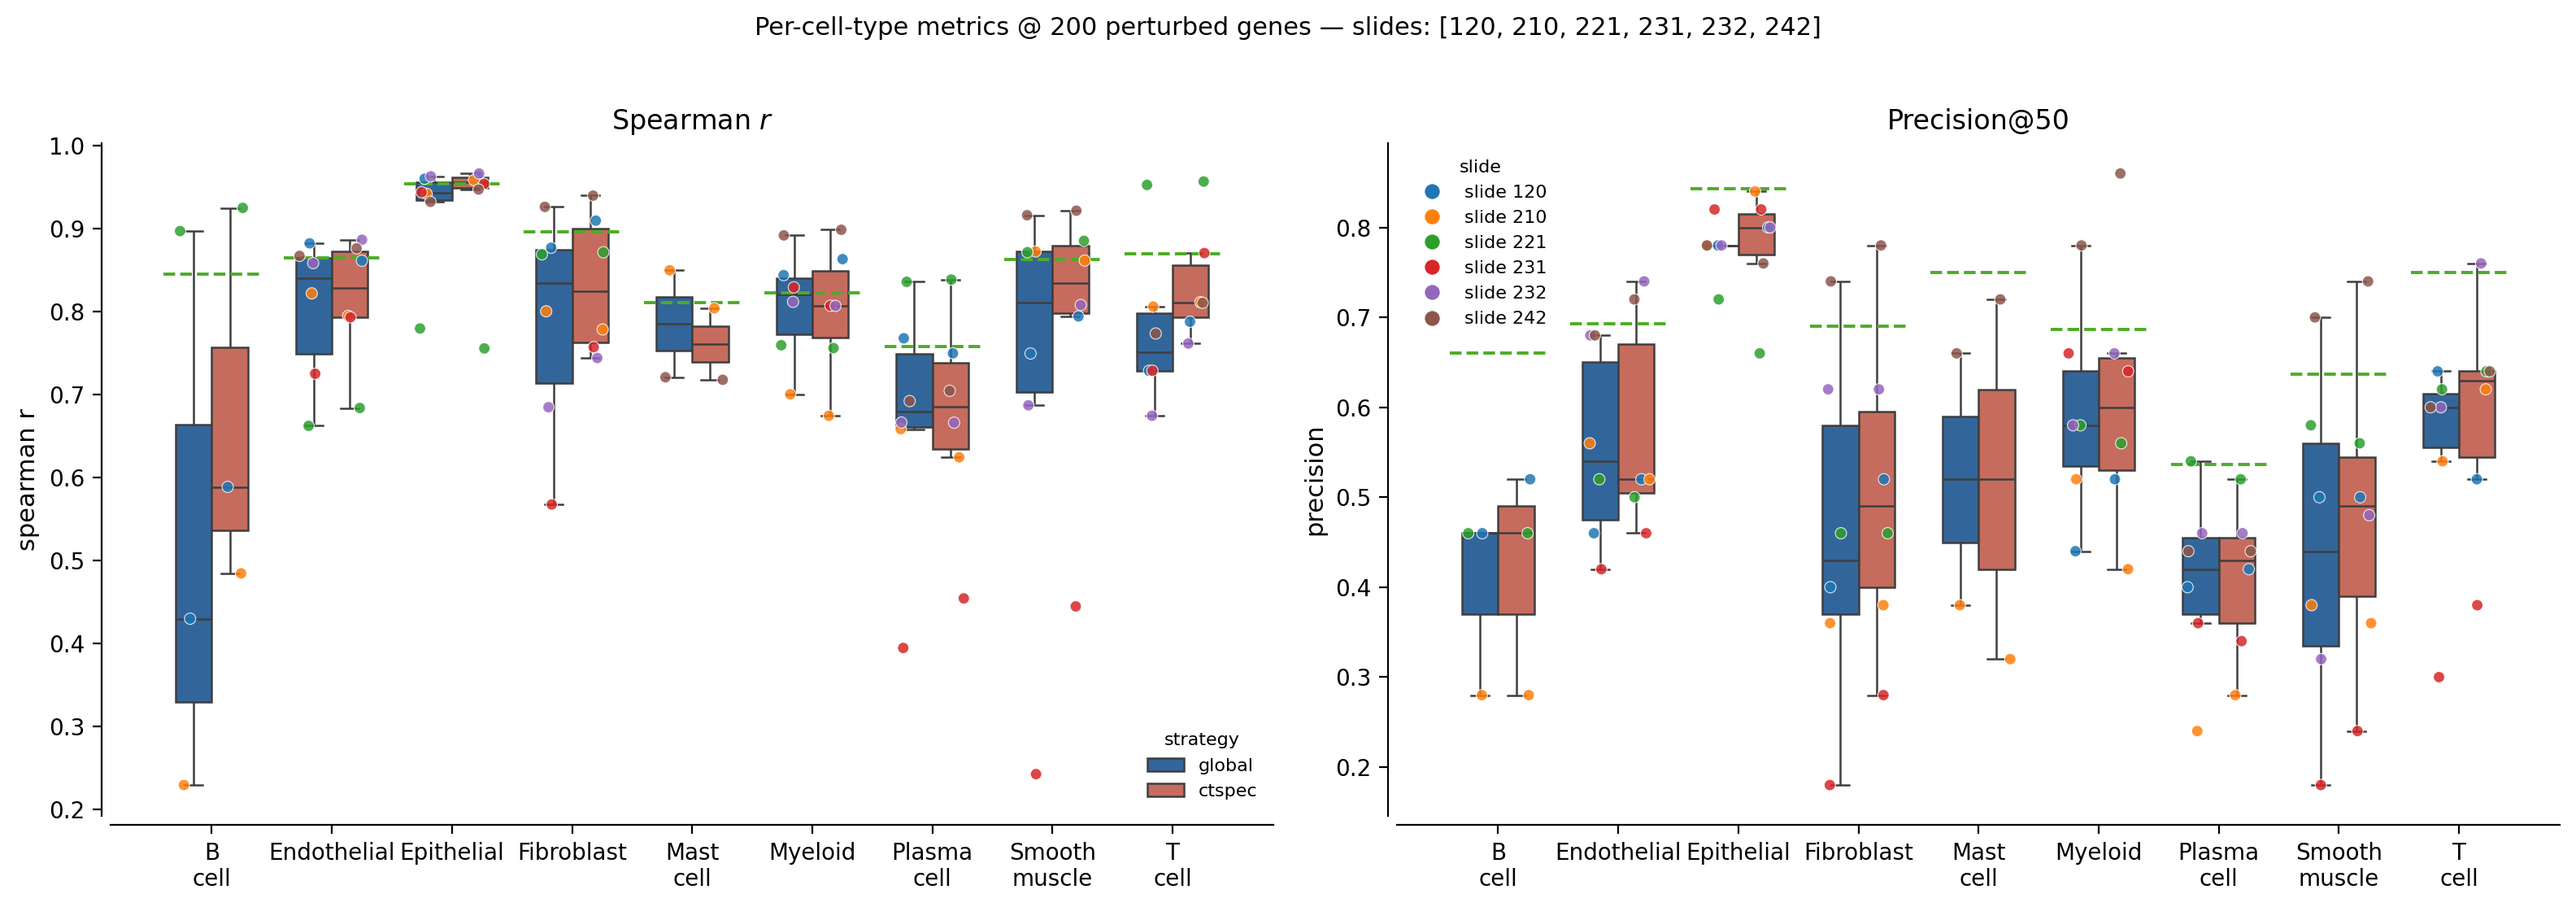

In [7]:
import numpy as np

cell_types = sorted(ct_at_200['cell_type'].unique().tolist())
strategies = ['global', 'ctspec']
strategy_palette = {'global': BLUE, 'ctspec': ORANGE}

plot_specs = [
    ('spearman_r', r'Spearman $r$'),
    ('precision',  'Precision@50'),
]

slides = sorted(ct_at_200['slide_id'].unique())
slide_cmap = dict(zip(slides, sns.color_palette('tab10', n_colors=len(slides))))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
rng = np.random.default_rng(0)

for ax, (metric, title) in zip(axes, plot_specs):
    sns.boxplot(
        data=ct_at_200, x='cell_type', y=metric, hue='strategy',
        order=cell_types, hue_order=strategies,
        palette=strategy_palette,
        ax=ax, width=0.6, linewidth=0.9,
        flierprops=dict(marker='', markersize=0),
    )

    # Manual point overlay: offset by strategy (to match dodged boxes), color by slide_id
    for ct_idx, ct in enumerate(cell_types):
        for strat_idx, strat in enumerate(strategies):
            sub = ct_at_200[(ct_at_200['cell_type'] == ct) &
                            (ct_at_200['strategy'] == strat)]
            if len(sub) == 0:
                continue
            offset = -0.2 if strat_idx == 0 else 0.2
            xs = ct_idx + offset + rng.uniform(-0.07, 0.07, len(sub))
            colors = [slide_cmap[s] for s in sub['slide_id']]
            ax.scatter(xs, sub[metric].values, c=colors,
                       s=25, alpha=0.85, zorder=4,
                       edgecolors='white', linewidths=0.4)

    # Per-cell-type edge-swap baseline (spans both strategy boxes)
    bl_sub = ct_baseline[ct_baseline['strategy'] == 'edge_swap']
    for xi, ct in enumerate(cell_types):
        ct_bl = bl_sub[bl_sub['cell_type'] == ct][metric]
        if len(ct_bl) > 0:
            ax.hlines(ct_bl.mean(), xi - 0.4, xi + 0.4,
                      colors=GREEN, linewidths=1.4, linestyles='--', zorder=3)

    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(metric.replace('_', ' '))
    ax.set_xticks(range(len(cell_types)))
    ax.set_xticklabels([ct.replace('_', '\n') for ct in cell_types],
                       rotation=0, fontsize=9)
    ax.spines['left'].set_position(('outward', 4))
    ax.spines['bottom'].set_position(('outward', 4))

    # Legends: strategy on the left panel, slide_id on the right panel
    if ax is axes[0]:
        strat_handles, strat_labels = ax.get_legend_handles_labels()
        ax.legend(strat_handles, strat_labels, title='strategy',
                  loc='best', frameon=False, fontsize=8, title_fontsize=8)
    else:
        if ax.get_legend():
            ax.get_legend().remove()
        slide_handles = [plt.Line2D([0], [0], marker='o', color='w',
                                    markerfacecolor=slide_cmap[s],
                                    markeredgecolor='white', markeredgewidth=0.4,
                                    markersize=7, label=f'slide {s}')
                         for s in slides]
        ax.legend(handles=slide_handles, title='slide',
                  loc='best', frameon=False, fontsize=8, title_fontsize=8)

fig.suptitle(f'Per-cell-type metrics @ 200 perturbed genes — slides: {slide_ids}',
             fontsize=11, y=1.01)
fig.tight_layout()
plt.show()